# Exploratory Data Analysis: Inditex Recommender System

This notebook provides a comprehensive analysis of the Inditex/Zara e-commerce dataset, querying directly from the dbt-powered DuckDB pipeline.

**Dataset overview:**
- ~46.5M training interactions across 4.57M sessions
- 43,692 products with CV embeddings
- 557K unique users with RFM metrics
- 7,349 test sessions to generate recommendations for

**Sections:**
1. Data Overview & Quality
2. User Analysis
3. Product Analysis
4. Session Analysis
5. Interaction Patterns & Conversion Funnel
6. Cold-Start Analysis (Train/Test Overlap)
7. Feature Correlations
8. Key Findings & Recommender Strategy

In [1]:
import duckdb
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
import numpy as np
from pathlib import Path

# Style
sns.set_theme(style="whitegrid", palette="muted")
plt.rcParams['figure.figsize'] = (14, 6)
plt.rcParams['figure.dpi'] = 100
plt.rcParams['font.size'] = 11

# Connect to the dbt DuckDB database
DB_PATH = Path("../transform/target/inditex_recommender.duckdb")
con = duckdb.connect(str(DB_PATH), read_only=True)

def q(sql):
    """Execute SQL and return a pandas DataFrame."""
    return con.sql(sql).df()

print("Connected to DuckDB pipeline")
print(f"Tables available: {[r[0] for r in con.sql('SELECT table_name FROM information_schema.tables ORDER BY table_schema, table_name').fetchall()]}")

Connected to DuckDB pipeline
Tables available: ['feat_product_popularity', 'feat_recommendation_input', 'feat_session_context', 'feat_user_behavior', 'int_product_stats', 'int_sessions', 'int_user_product_interactions', 'int_user_profiles', 'dim_products', 'dim_sessions', 'dim_users', 'fct_interactions', 'stg_api_users', 'stg_interactions_test', 'stg_interactions_train', 'stg_products', 'stg_users']


---
## 1. Data Overview & Quality

Let's start by understanding the shape, completeness, and basic statistics of each layer.

In [2]:
# Row counts across all pipeline layers
row_counts = q("""
    SELECT 'stg_interactions_train' as table_name, 'staging' as layer, count(*) as rows FROM staging.stg_interactions_train
    UNION ALL SELECT 'stg_interactions_test', 'staging', count(*) FROM staging.stg_interactions_test
    UNION ALL SELECT 'stg_products', 'staging', count(*) FROM staging.stg_products
    UNION ALL SELECT 'stg_users', 'staging', count(*) FROM staging.stg_users
    UNION ALL SELECT 'stg_api_users', 'staging', count(*) FROM staging.stg_api_users
    UNION ALL SELECT 'int_sessions', 'intermediate', count(*) FROM intermediate.int_sessions
    UNION ALL SELECT 'int_product_stats', 'intermediate', count(*) FROM intermediate.int_product_stats
    UNION ALL SELECT 'int_user_profiles', 'intermediate', count(*) FROM intermediate.int_user_profiles
    UNION ALL SELECT 'dim_products', 'marts', count(*) FROM marts.dim_products
    UNION ALL SELECT 'dim_users', 'marts', count(*) FROM marts.dim_users
    UNION ALL SELECT 'dim_sessions', 'marts', count(*) FROM marts.dim_sessions
    UNION ALL SELECT 'fct_interactions', 'marts', count(*) FROM marts.fct_interactions
    UNION ALL SELECT 'feat_user_behavior', 'features', count(*) FROM features.feat_user_behavior
    UNION ALL SELECT 'feat_product_popularity', 'features', count(*) FROM features.feat_product_popularity
    UNION ALL SELECT 'feat_session_context', 'features', count(*) FROM features.feat_session_context
    UNION ALL SELECT 'feat_recommendation_input', 'features', count(*) FROM features.feat_recommendation_input
""")
row_counts['rows'] = row_counts['rows'].apply(lambda x: f"{x:,.0f}")
print(row_counts.to_string(index=False))

               table_name        layer       rows
   stg_interactions_train      staging 46,551,445
    stg_interactions_test      staging     29,275
             stg_products      staging     43,692
                stg_users      staging    577,494
            stg_api_users      staging    577,494
             int_sessions intermediate  4,574,211
        int_product_stats intermediate     41,995
        int_user_profiles intermediate    557,006
             dim_products        marts     43,692
                dim_users        marts    557,006
             dim_sessions        marts  4,574,211
         fct_interactions        marts 46,580,720
       feat_user_behavior     features    557,006
  feat_product_popularity     features     43,692
     feat_session_context     features      7,349
feat_recommendation_input     features      7,349


In [3]:
# Key data quality metrics
quality = q("""
    SELECT
        count(*) as total_interactions,
        count(*) filter (where is_anonymous) as anonymous_interactions,
        round(count(*) filter (where is_anonymous)::double / count(*) * 100, 1) as anonymous_pct,
        count(distinct session_id) as unique_sessions,
        count(distinct user_id) as unique_known_users,
        count(distinct product_id) as unique_products,
        count(distinct country_id) as unique_countries,
        sum(is_added_to_cart) as total_cart_adds,
        round(sum(is_added_to_cart)::double / count(*) * 100, 2) as overall_conversion_rate,
        min(interaction_date) as date_start,
        max(interaction_date) as date_end,
        count(distinct interaction_date) as total_days,
        count(*) filter (where page_type_id is null) as null_pagetypes
    FROM staging.stg_interactions_train
""")
print("=== Training Data Quality Summary ===")
for col in quality.columns:
    print(f"  {col}: {quality[col].values[0]}")

=== Training Data Quality Summary ===
  total_interactions: 46551445
  anonymous_interactions: 39694715
  anonymous_pct: 85.3
  unique_sessions: 4573756
  unique_known_users: 380052
  unique_products: 41995
  unique_countries: 4
  total_cart_adds: 2745783.0
  overall_conversion_rate: 5.9
  date_start: 2024-06-01T00:00:00.000000
  date_end: 2024-06-16T00:00:00.000000
  total_days: 16
  null_pagetypes: 1197


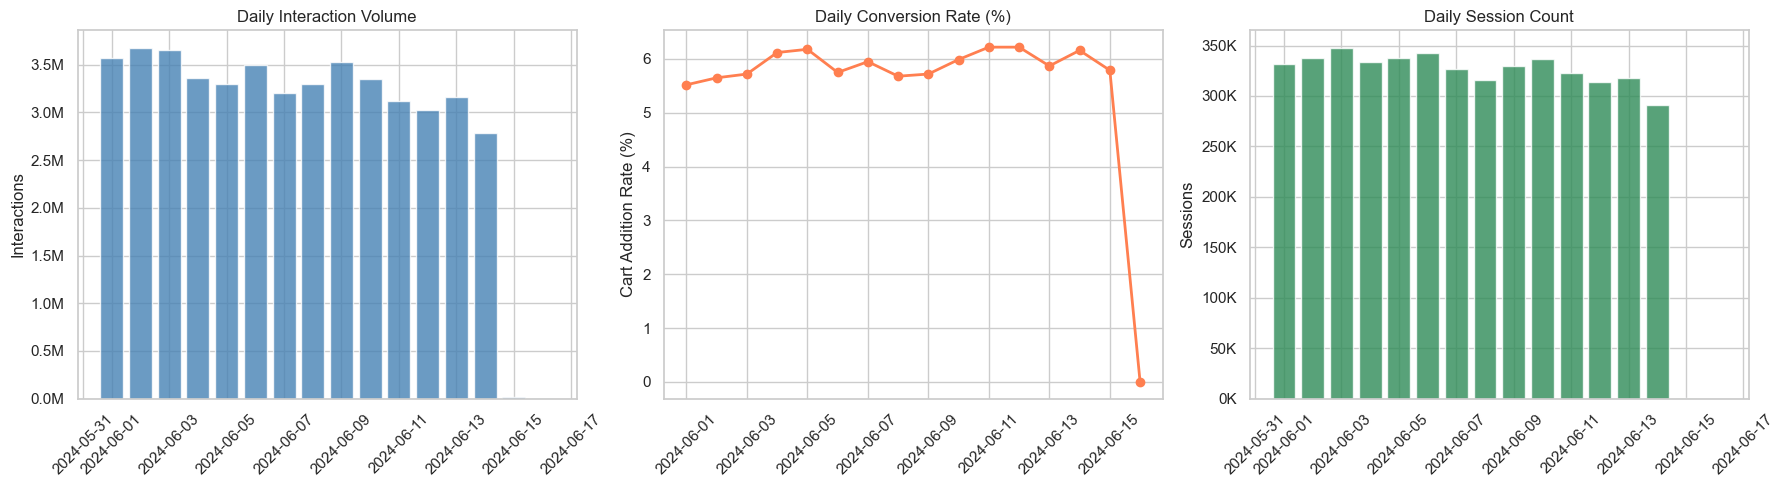

In [4]:
# Daily interaction volume and conversion rate
daily = q("""
    SELECT
        interaction_date,
        count(*) as interactions,
        sum(is_added_to_cart) as cart_adds,
        round(sum(is_added_to_cart)::double / count(*) * 100, 2) as conversion_rate,
        count(distinct session_id) as sessions,
        count(distinct user_id) filter (where not is_anonymous) as known_users
    FROM staging.stg_interactions_train
    GROUP BY interaction_date
    ORDER BY interaction_date
""")

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

axes[0].bar(daily['interaction_date'], daily['interactions'], color='steelblue', alpha=0.8)
axes[0].set_title('Daily Interaction Volume')
axes[0].set_ylabel('Interactions')
axes[0].yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{x/1e6:.1f}M'))
axes[0].tick_params(axis='x', rotation=45)

axes[1].plot(daily['interaction_date'], daily['conversion_rate'], 'o-', color='coral', linewidth=2)
axes[1].set_title('Daily Conversion Rate (%)')
axes[1].set_ylabel('Cart Addition Rate (%)')
axes[1].tick_params(axis='x', rotation=45)

axes[2].bar(daily['interaction_date'], daily['sessions'], color='seagreen', alpha=0.8)
axes[2].set_title('Daily Session Count')
axes[2].set_ylabel('Sessions')
axes[2].yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{x/1e3:.0f}K'))
axes[2].tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.show()

---
## 2. User Analysis

Understanding user segments, RFM distributions, and behavioral patterns. The 85% anonymous rate is a major challenge for the recommender.

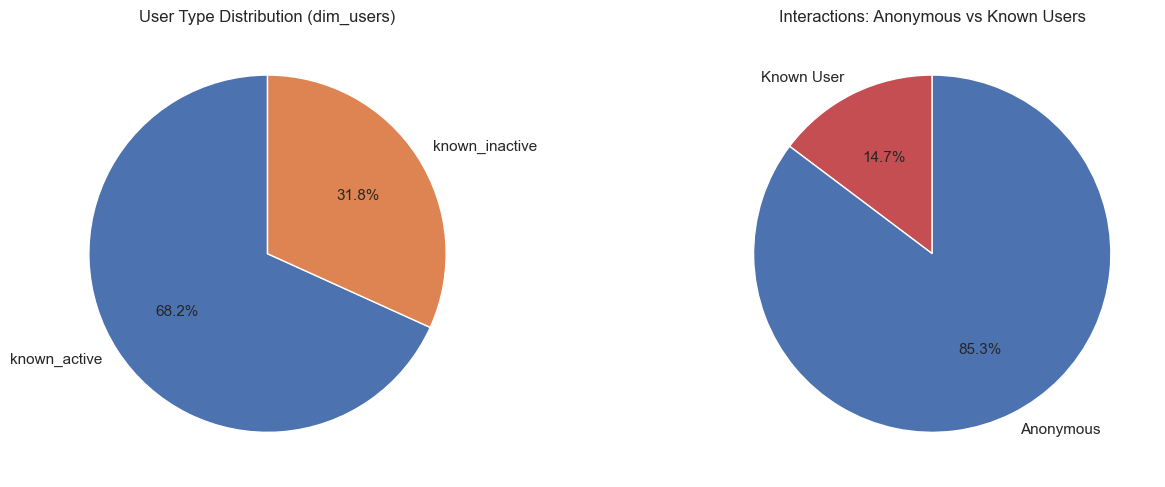


User types:
     user_type  user_count
  known_active      380052
known_inactive      176954

Anonymous interactions:  user_type  interactions
Known User       6856730
 Anonymous      39694715


In [5]:
# User type distribution
user_types = q("""
    SELECT user_type, count(*) as user_count
    FROM marts.dim_users
    GROUP BY user_type
    ORDER BY user_count DESC
""")

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Pie chart of user types
colors = ['#4C72B0', '#DD8452', '#55A868', '#C44E52']
axes[0].pie(user_types['user_count'], labels=user_types['user_type'],
            autopct='%1.1f%%', colors=colors, startangle=90)
axes[0].set_title('User Type Distribution (dim_users)')

# Anonymous vs known interaction split
anon_split = q("""
    SELECT
        CASE WHEN is_anonymous THEN 'Anonymous' ELSE 'Known User' END as user_type,
        count(*) as interactions
    FROM staging.stg_interactions_train
    GROUP BY 1
""")
axes[1].pie(anon_split['interactions'], labels=anon_split['user_type'],
            autopct='%1.1f%%', colors=['#C44E52', '#4C72B0'], startangle=90)
axes[1].set_title('Interactions: Anonymous vs Known Users')

plt.tight_layout()
plt.show()

print(f"\nUser types:\n{user_types.to_string(index=False)}")
print(f"\nAnonymous interactions: {anon_split.to_string(index=False)}")

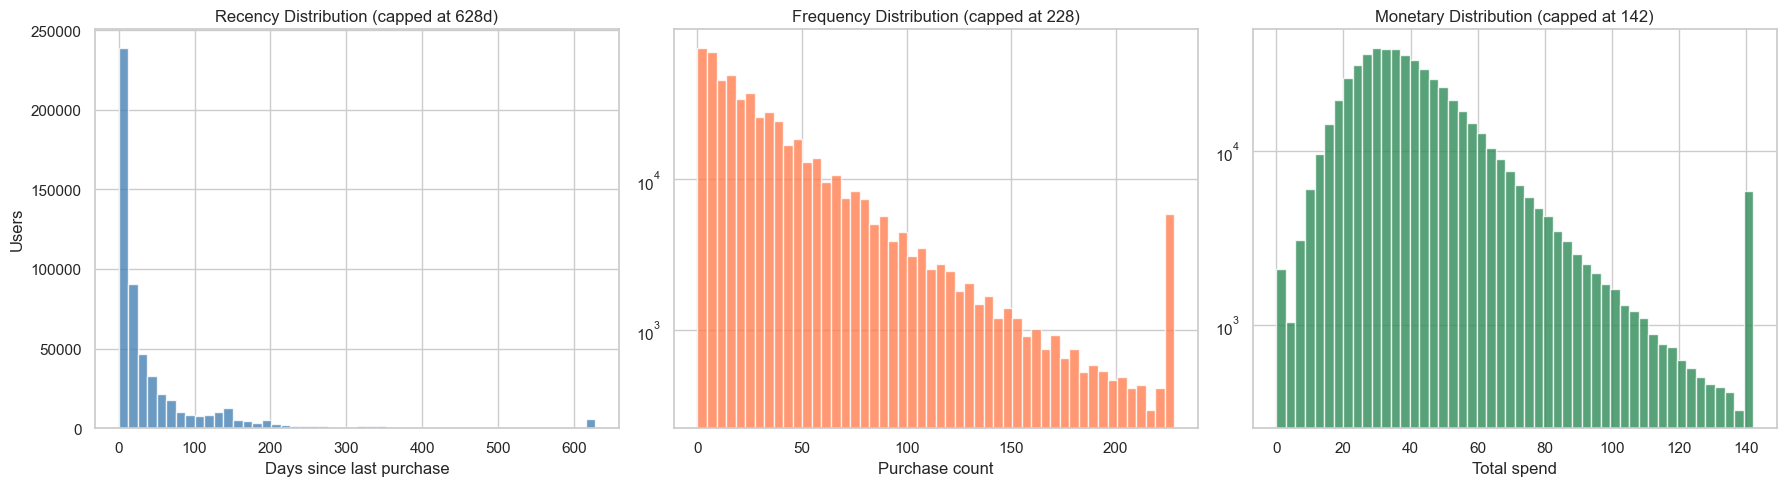

RFM Summary Statistics:
         recency  frequency  monetary_value
count  557006.00  557006.00       557006.00
mean       58.13      37.73          190.65
std       115.75      59.26        15367.30
min         0.00       0.00            0.00
25%         5.00       9.00           27.66
50%        18.00      23.00           37.95
75%        56.00      48.00           51.72
max      1095.00   10754.00      5700000.00


In [6]:
# RFM distributions
rfm = q("""
    SELECT recency, frequency, monetary_value
    FROM intermediate.int_user_profiles
    WHERE recency IS NOT NULL
""")

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# Recency (capped at 99th percentile for visibility)
cap_r = rfm['recency'].quantile(0.99)
axes[0].hist(rfm['recency'].clip(upper=cap_r), bins=50, color='steelblue', alpha=0.8, edgecolor='white')
axes[0].set_title(f'Recency Distribution (capped at {cap_r:.0f}d)')
axes[0].set_xlabel('Days since last purchase')
axes[0].set_ylabel('Users')

# Frequency (log scale)
cap_f = rfm['frequency'].quantile(0.99)
axes[1].hist(rfm['frequency'].clip(upper=cap_f), bins=50, color='coral', alpha=0.8, edgecolor='white')
axes[1].set_title(f'Frequency Distribution (capped at {cap_f:.0f})')
axes[1].set_xlabel('Purchase count')
axes[1].set_yscale('log')

# Monetary (log scale)
cap_m = rfm['monetary_value'].quantile(0.99)
axes[2].hist(rfm['monetary_value'].clip(upper=cap_m), bins=50, color='seagreen', alpha=0.8, edgecolor='white')
axes[2].set_title(f'Monetary Distribution (capped at {cap_m:.0f})')
axes[2].set_xlabel('Total spend')
axes[2].set_yscale('log')

plt.tight_layout()
plt.show()

print("RFM Summary Statistics:")
print(rfm.describe().round(2).to_string())

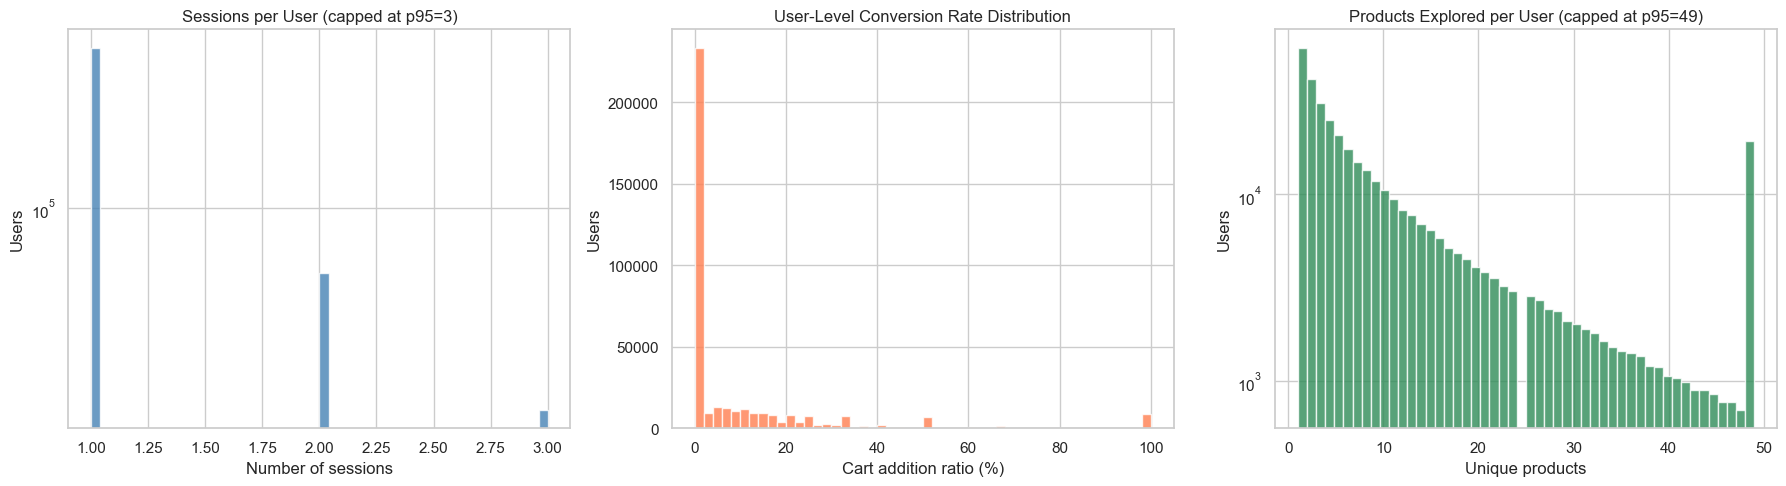

Conversion Rate by Activity Level:
session_bucket  users  avg_cart_ratio  avg_products
             1 288337            9.35          10.9
           2-5  90521            8.63          24.3
          6-20   1194            8.81          57.8


In [7]:
# User activity distribution: sessions per user & conversion rate by activity level
user_activity = q("""
    SELECT
        total_sessions,
        total_interactions,
        total_cart_additions,
        overall_cart_ratio,
        unique_products_interacted
    FROM marts.dim_users
    WHERE total_sessions > 0
""")

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# Sessions per user
cap_s = user_activity['total_sessions'].quantile(0.95)
axes[0].hist(user_activity['total_sessions'].clip(upper=cap_s), bins=50,
             color='steelblue', alpha=0.8, edgecolor='white')
axes[0].set_title(f'Sessions per User (capped at p95={cap_s:.0f})')
axes[0].set_xlabel('Number of sessions')
axes[0].set_ylabel('Users')
axes[0].set_yscale('log')

# Cart ratio distribution
axes[1].hist(user_activity['overall_cart_ratio'], bins=50, color='coral', alpha=0.8, edgecolor='white')
axes[1].set_title('User-Level Conversion Rate Distribution')
axes[1].set_xlabel('Cart addition ratio (%)')
axes[1].set_ylabel('Users')

# Products explored per user
cap_p = user_activity['unique_products_interacted'].quantile(0.95)
axes[2].hist(user_activity['unique_products_interacted'].clip(upper=cap_p), bins=50,
             color='seagreen', alpha=0.8, edgecolor='white')
axes[2].set_title(f'Products Explored per User (capped at p95={cap_p:.0f})')
axes[2].set_xlabel('Unique products')
axes[2].set_ylabel('Users')
axes[2].set_yscale('log')

plt.tight_layout()
plt.show()

# Conversion rate by activity bucket
activity_buckets = q("""
    SELECT
        CASE
            WHEN total_sessions <= 1 THEN '1'
            WHEN total_sessions <= 5 THEN '2-5'
            WHEN total_sessions <= 20 THEN '6-20'
            WHEN total_sessions <= 50 THEN '21-50'
            ELSE '50+'
        END as session_bucket,
        count(*) as users,
        round(avg(overall_cart_ratio), 2) as avg_cart_ratio,
        round(avg(unique_products_interacted), 1) as avg_products
    FROM marts.dim_users
    WHERE total_sessions > 0
    GROUP BY 1
    ORDER BY min(total_sessions)
""")
print("Conversion Rate by Activity Level:")
print(activity_buckets.to_string(index=False))

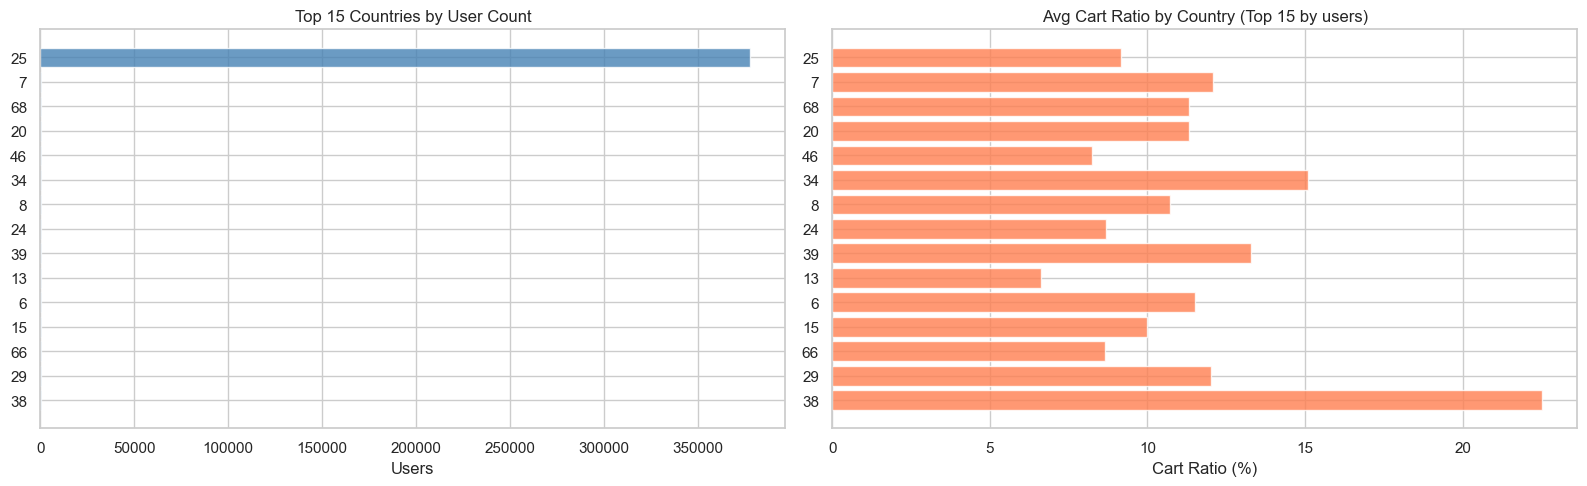


Multi-country user distribution:
 country_count  users
             1 539853
             2  14929
             3   1557
             4    425
             5    134
             6     62
             7     25
             8     12
             9      4
            10      3
            12      1
            21      1


In [8]:
# Top countries by user count and interactions
country_stats = q("""
    SELECT
        primary_country_id as country,
        count(*) as users,
        sum(total_interactions) as interactions,
        round(avg(overall_cart_ratio), 2) as avg_cart_ratio,
        sum((country_count > 1)::int) as multi_country_users
    FROM marts.dim_users
    WHERE total_sessions > 0
    GROUP BY 1
    ORDER BY users DESC
    LIMIT 15
""")

fig, axes = plt.subplots(1, 2, figsize=(16, 5))

axes[0].barh(country_stats['country'].astype(str), country_stats['users'], color='steelblue', alpha=0.8)
axes[0].set_title('Top 15 Countries by User Count')
axes[0].set_xlabel('Users')
axes[0].invert_yaxis()

axes[1].barh(country_stats['country'].astype(str), country_stats['avg_cart_ratio'], color='coral', alpha=0.8)
axes[1].set_title('Avg Cart Ratio by Country (Top 15 by users)')
axes[1].set_xlabel('Cart Ratio (%)')
axes[1].invert_yaxis()

plt.tight_layout()
plt.show()

# Multi-country users
multi_country = q("""
    SELECT country_count, count(*) as users
    FROM intermediate.int_user_profiles
    GROUP BY 1
    ORDER BY 1
""")
print(f"\nMulti-country user distribution:\n{multi_country.to_string(index=False)}")

---
## 3. Product Analysis

Understanding the product catalog, popularity distribution (long-tail), discount impact, and category structure.

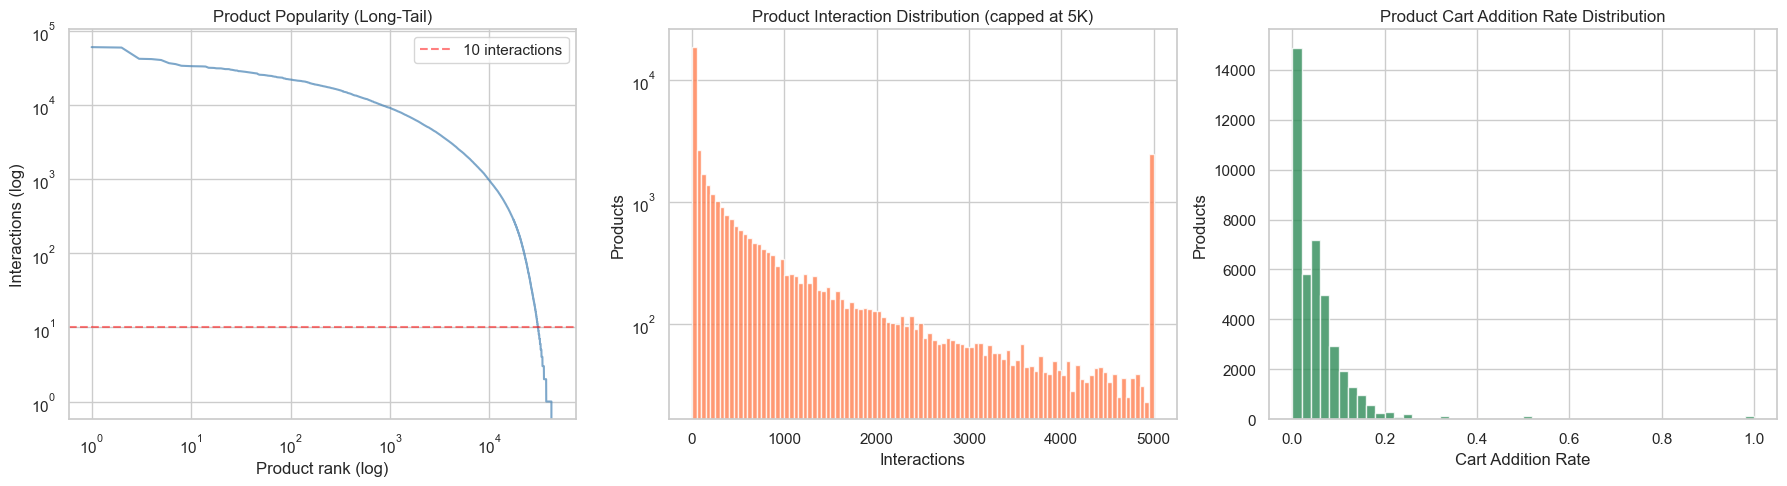

Products with 0 interactions: 1,697
Products with >= 100 interactions: 22,389
Top 1% products account for 18.2% of all interactions


In [9]:
# Product popularity distribution (long-tail analysis)
product_pop = q("""
    SELECT
        product_id,
        total_interactions,
        total_cart_additions,
        cart_addition_rate,
        has_discount,
        family_id,
        section_id,
        global_popularity_rank
    FROM features.feat_product_popularity
    ORDER BY total_interactions DESC
""")

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# Long-tail: log-log plot
sorted_interactions = product_pop['total_interactions'].sort_values(ascending=False).values
axes[0].loglog(range(1, len(sorted_interactions) + 1), sorted_interactions, color='steelblue', alpha=0.7)
axes[0].set_title('Product Popularity (Long-Tail)')
axes[0].set_xlabel('Product rank (log)')
axes[0].set_ylabel('Interactions (log)')
axes[0].axhline(y=10, color='red', linestyle='--', alpha=0.5, label='10 interactions')
axes[0].legend()

# Interaction distribution (histogram)
axes[1].hist(product_pop['total_interactions'].clip(upper=5000), bins=100,
             color='coral', alpha=0.8, edgecolor='white')
axes[1].set_title('Product Interaction Distribution (capped at 5K)')
axes[1].set_xlabel('Interactions')
axes[1].set_ylabel('Products')
axes[1].set_yscale('log')

# Cart rate distribution (only for products with interactions)
has_interactions = product_pop[product_pop['total_interactions'] > 0]
axes[2].hist(has_interactions['cart_addition_rate'], bins=50, color='seagreen', alpha=0.8, edgecolor='white')
axes[2].set_title('Product Cart Addition Rate Distribution')
axes[2].set_xlabel('Cart Addition Rate')
axes[2].set_ylabel('Products')

plt.tight_layout()
plt.show()

# Key stats
print(f"Products with 0 interactions: {(product_pop['total_interactions'] == 0).sum():,}")
print(f"Products with >= 100 interactions: {(product_pop['total_interactions'] >= 100).sum():,}")
print(f"Top 1% products account for {product_pop.nlargest(int(len(product_pop) * 0.01), 'total_interactions')['total_interactions'].sum() / product_pop['total_interactions'].sum() * 100:.1f}% of all interactions")

Discount Impact on Product Performance:
 has_discount  products  avg_interactions  avg_cart_rate  avg_sessions  total_interactions
            0     40617            1070.3         0.0536         846.0          43470973.0
            1      1378            2235.5         0.0723        1813.1           3080472.0


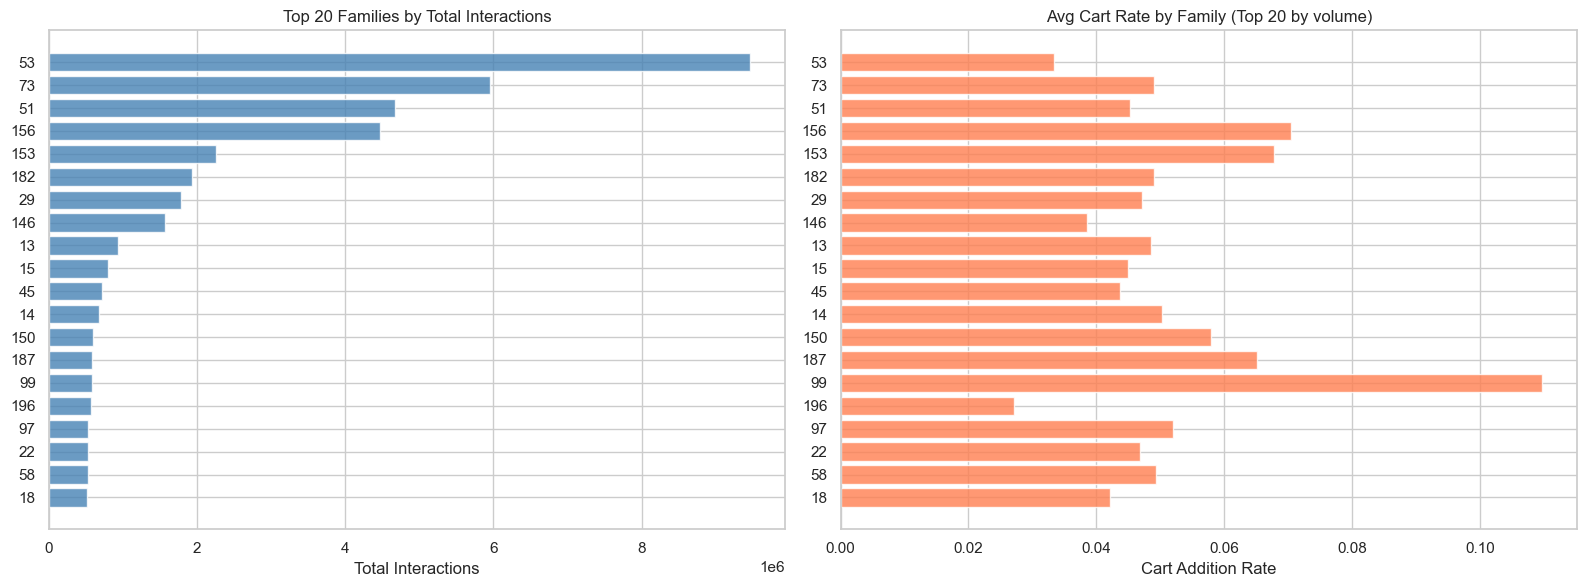

In [10]:
# Discount impact on conversion
discount_impact = q("""
    SELECT
        has_discount,
        count(*) as products,
        round(avg(total_interactions), 1) as avg_interactions,
        round(avg(cart_addition_rate), 4) as avg_cart_rate,
        round(avg(unique_sessions), 1) as avg_sessions,
        sum(total_interactions) as total_interactions
    FROM marts.dim_products
    WHERE total_interactions > 0
    GROUP BY 1
""")
print("Discount Impact on Product Performance:")
print(discount_impact.to_string(index=False))

# Family analysis: top families by product count and conversion
family_stats = q("""
    SELECT
        family_id,
        count(*) as product_count,
        round(avg(cart_addition_rate), 4) as avg_cart_rate,
        sum(total_interactions) as total_interactions,
        sum(total_cart_additions) as total_cart_adds
    FROM marts.dim_products
    WHERE total_interactions > 0
    GROUP BY 1
    HAVING count(*) >= 10
    ORDER BY total_interactions DESC
    LIMIT 20
""")

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

top_families = family_stats.head(20)
axes[0].barh(top_families['family_id'].astype(str), top_families['total_interactions'],
             color='steelblue', alpha=0.8)
axes[0].set_title('Top 20 Families by Total Interactions')
axes[0].set_xlabel('Total Interactions')
axes[0].invert_yaxis()

axes[1].barh(top_families['family_id'].astype(str), top_families['avg_cart_rate'],
             color='coral', alpha=0.8)
axes[1].set_title('Avg Cart Rate by Family (Top 20 by volume)')
axes[1].set_xlabel('Cart Addition Rate')
axes[1].invert_yaxis()

plt.tight_layout()
plt.show()

In [11]:
# Section analysis
section_stats = q("""
    SELECT
        section_id,
        count(*) as products,
        sum(total_interactions) as interactions,
        sum(total_cart_additions) as cart_adds,
        round(avg(cart_addition_rate), 4) as avg_cart_rate,
        count(distinct family_id) as families
    FROM marts.dim_products
    GROUP BY 1
    ORDER BY interactions DESC
""")
print("Product Sections Overview:")
print(section_stats.to_string(index=False))

# Product catalog vs actually interacted
catalog_coverage = q("""
    SELECT
        count(*) as total_products,
        count(*) filter (where total_interactions > 0) as products_with_interactions,
        count(*) filter (where total_interactions = 0) as products_never_seen,
        count(*) filter (where total_cart_additions > 0) as products_ever_carted,
        round(count(*) filter (where total_interactions > 0)::double / count(*) * 100, 1) as catalog_coverage_pct
    FROM marts.dim_products
""")
print(f"\nCatalog Coverage:")
for col in catalog_coverage.columns:
    print(f"  {col}: {catalog_coverage[col].values[0]}")

Product Sections Overview:
 section_id  products  interactions  cart_adds  avg_cart_rate  families
        1.0     18325    36780677.0  1984644.0         0.0440        95
        3.0      9540     5383462.0   560519.0         0.0845        92
        4.0      8969     3988777.0   182679.0         0.0356        58
        2.0      6768      360041.0    16286.0         0.0497        80
        NaN        90       38488.0     1655.0         0.1069        33

Catalog Coverage:
  total_products: 43692
  products_with_interactions: 41995
  products_never_seen: 1697
  products_ever_carted: 29107
  catalog_coverage_pct: 96.1


---
## 4. Session Analysis

Session duration, interaction depth, device types, temporal patterns, and how they correlate with conversion.

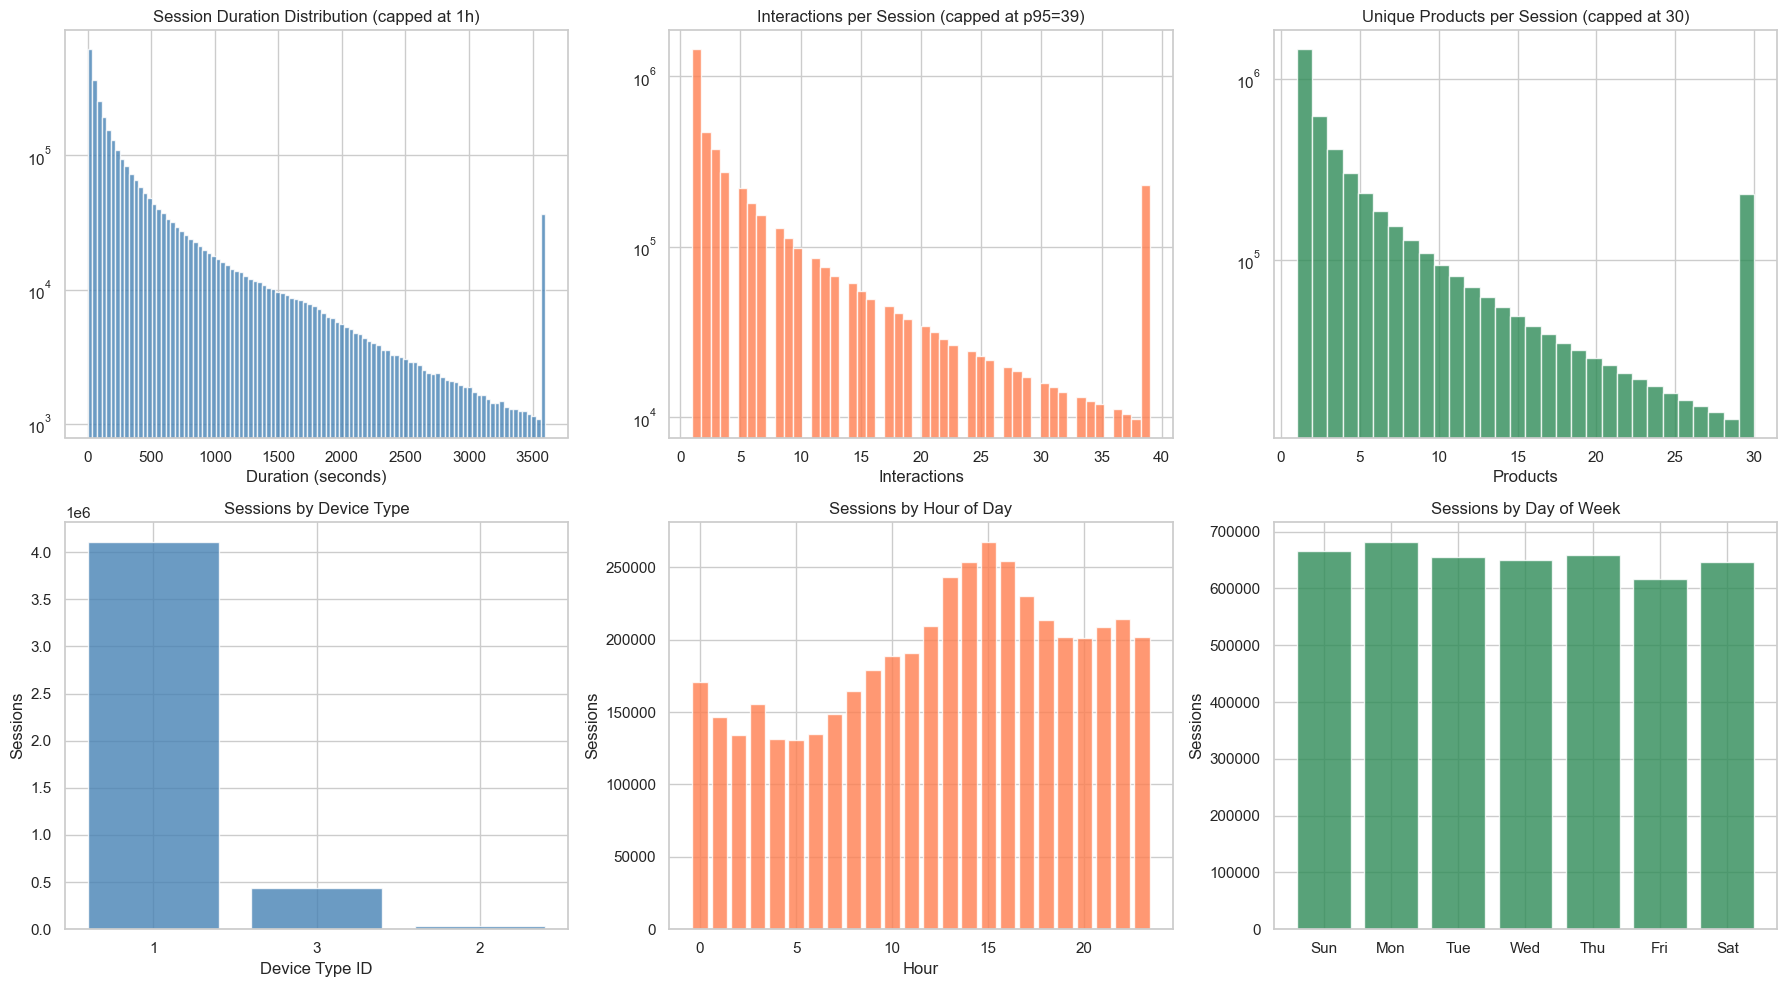

Session Statistics:
  Zero-duration sessions (single interaction): 1,448,290 (31.7%)
  Median duration (>0): 174s
  Median interactions: 3
  Sessions with cart adds: 1,038,136 (22.7%)


In [12]:
# Session duration and depth distributions
session_data = q("""
    SELECT
        session_duration_seconds,
        total_interactions,
        unique_products_viewed,
        products_added_to_cart,
        cart_addition_ratio,
        is_anonymous,
        primary_device_type,
        day_of_week,
        hour_of_day
    FROM marts.dim_sessions
""")

fig, axes = plt.subplots(2, 3, figsize=(18, 10))

# Session duration (capped at 1 hour)
dur = session_data['session_duration_seconds'].clip(upper=3600)
axes[0, 0].hist(dur[dur > 0], bins=100, color='steelblue', alpha=0.8, edgecolor='white')
axes[0, 0].set_title('Session Duration Distribution (capped at 1h)')
axes[0, 0].set_xlabel('Duration (seconds)')
axes[0, 0].set_yscale('log')

# Interactions per session
cap_int = session_data['total_interactions'].quantile(0.95)
axes[0, 1].hist(session_data['total_interactions'].clip(upper=cap_int), bins=50,
                color='coral', alpha=0.8, edgecolor='white')
axes[0, 1].set_title(f'Interactions per Session (capped at p95={cap_int:.0f})')
axes[0, 1].set_xlabel('Interactions')
axes[0, 1].set_yscale('log')

# Products viewed per session
axes[0, 2].hist(session_data['unique_products_viewed'].clip(upper=30), bins=30,
                color='seagreen', alpha=0.8, edgecolor='white')
axes[0, 2].set_title('Unique Products per Session (capped at 30)')
axes[0, 2].set_xlabel('Products')
axes[0, 2].set_yscale('log')

# Device type breakdown
device_counts = session_data['primary_device_type'].value_counts().head(10)
axes[1, 0].bar(device_counts.index.astype(str), device_counts.values, color='steelblue', alpha=0.8)
axes[1, 0].set_title('Sessions by Device Type')
axes[1, 0].set_xlabel('Device Type ID')
axes[1, 0].set_ylabel('Sessions')

# Hour of day distribution
hourly = session_data['hour_of_day'].value_counts().sort_index()
axes[1, 1].bar(hourly.index, hourly.values, color='coral', alpha=0.8)
axes[1, 1].set_title('Sessions by Hour of Day')
axes[1, 1].set_xlabel('Hour')
axes[1, 1].set_ylabel('Sessions')

# Day of week distribution
dow_labels = {1: 'Mon', 2: 'Tue', 3: 'Wed', 4: 'Thu', 5: 'Fri', 6: 'Sat', 0: 'Sun'}
dow = session_data['day_of_week'].value_counts().sort_index()
axes[1, 2].bar([dow_labels.get(d, str(d)) for d in dow.index], dow.values, color='seagreen', alpha=0.8)
axes[1, 2].set_title('Sessions by Day of Week')
axes[1, 2].set_ylabel('Sessions')

plt.tight_layout()
plt.show()

# Key session stats
print("Session Statistics:")
print(f"  Zero-duration sessions (single interaction): {(session_data['session_duration_seconds'] == 0).sum():,} ({(session_data['session_duration_seconds'] == 0).mean()*100:.1f}%)")
print(f"  Median duration (>0): {session_data[session_data['session_duration_seconds'] > 0]['session_duration_seconds'].median():.0f}s")
print(f"  Median interactions: {session_data['total_interactions'].median():.0f}")
print(f"  Sessions with cart adds: {(session_data['products_added_to_cart'] > 0).sum():,} ({(session_data['products_added_to_cart'] > 0).mean()*100:.1f}%)")

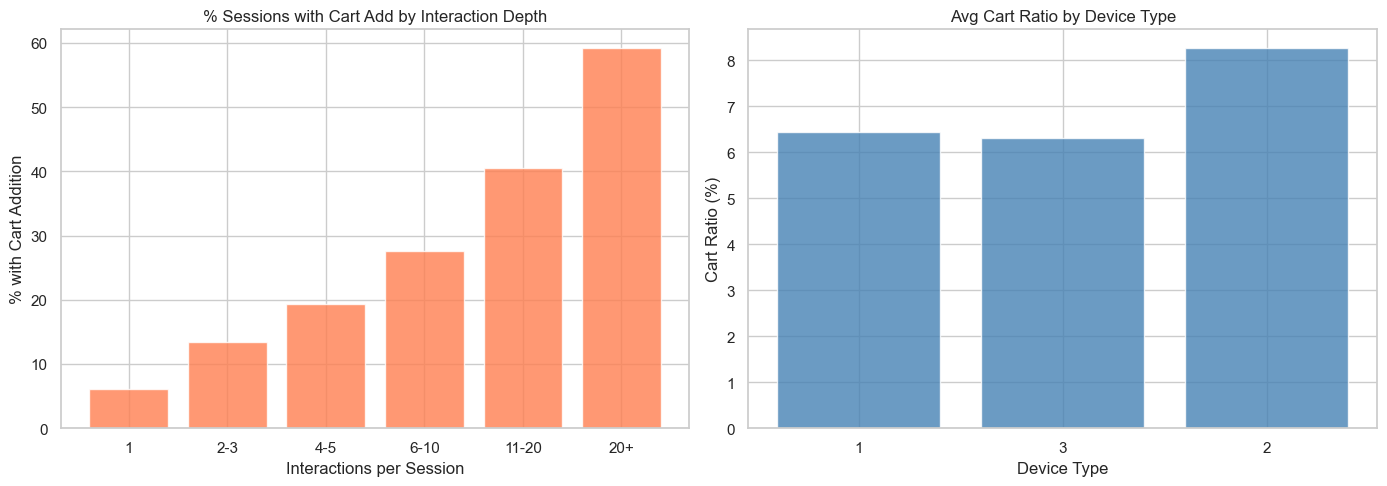

Conversion by Session Depth:
interaction_bucket  sessions  avg_cart_ratio  pct_with_cart_add
                 1   1448274            6.16               6.16
               2-3    845023            6.93              13.36
               4-5    494679            6.42              19.39
              6-10    675501            6.41              27.60
             11-20    553745            6.57              40.50
               20+    556989            6.33              59.15

Conversion by Device:
 primary_device_type  sessions  avg_cart_ratio  avg_duration  avg_interactions
                   1   4112235            6.44         315.2              10.5
                   3    432290            6.32         401.8               7.3
                   2     29686            8.26         538.8              14.7


In [13]:
# Conversion rate by session depth and device
conversion_by_depth = q("""
    SELECT
        CASE
            WHEN total_interactions = 1 THEN '1'
            WHEN total_interactions <= 3 THEN '2-3'
            WHEN total_interactions <= 5 THEN '4-5'
            WHEN total_interactions <= 10 THEN '6-10'
            WHEN total_interactions <= 20 THEN '11-20'
            ELSE '20+'
        END as interaction_bucket,
        count(*) as sessions,
        round(avg(cart_addition_ratio), 2) as avg_cart_ratio,
        round(sum((products_added_to_cart > 0)::int)::double / count(*) * 100, 2) as pct_with_cart_add
    FROM marts.dim_sessions
    GROUP BY 1
    ORDER BY min(total_interactions)
""")

conversion_by_device = q("""
    SELECT
        primary_device_type,
        count(*) as sessions,
        round(avg(cart_addition_ratio), 2) as avg_cart_ratio,
        round(avg(session_duration_seconds), 1) as avg_duration,
        round(avg(total_interactions), 1) as avg_interactions
    FROM marts.dim_sessions
    GROUP BY 1
    ORDER BY sessions DESC
    LIMIT 10
""")

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Conversion by session depth
x = range(len(conversion_by_depth))
axes[0].bar(x, conversion_by_depth['pct_with_cart_add'], color='coral', alpha=0.8)
axes[0].set_xticks(x)
axes[0].set_xticklabels(conversion_by_depth['interaction_bucket'])
axes[0].set_title('% Sessions with Cart Add by Interaction Depth')
axes[0].set_xlabel('Interactions per Session')
axes[0].set_ylabel('% with Cart Addition')

# Conversion by device
x2 = range(len(conversion_by_device))
axes[1].bar(x2, conversion_by_device['avg_cart_ratio'], color='steelblue', alpha=0.8)
axes[1].set_xticks(x2)
axes[1].set_xticklabels(conversion_by_device['primary_device_type'].astype(str))
axes[1].set_title('Avg Cart Ratio by Device Type')
axes[1].set_xlabel('Device Type')
axes[1].set_ylabel('Cart Ratio (%)')

plt.tight_layout()
plt.show()

print("Conversion by Session Depth:")
print(conversion_by_depth.to_string(index=False))
print(f"\nConversion by Device:")
print(conversion_by_device.to_string(index=False))

---
## 5. Interaction Patterns & Conversion Funnel

How users browse before adding to cart, repeat viewing behavior, and page type analysis.

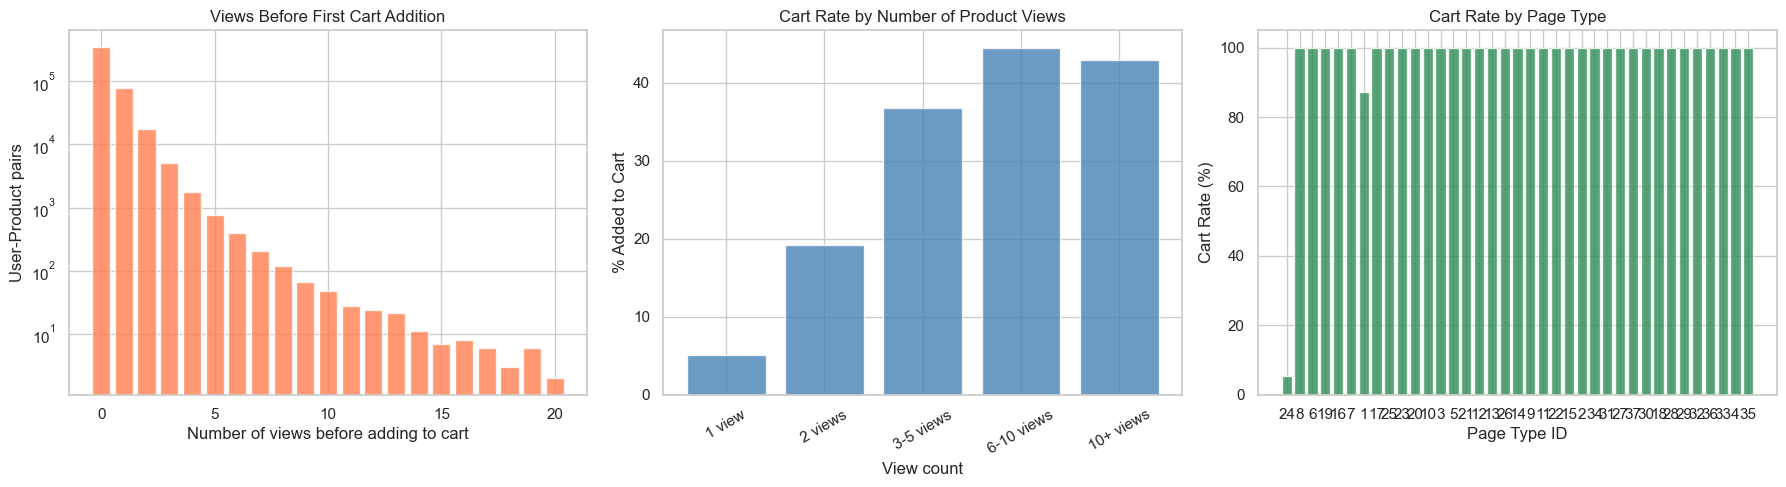

Repeat View Behavior:
view_bucket   pairs  pct_carted  avg_sessions
     1 view 4467461        5.02           1.0
    2 views  685358       19.20           1.1
  3-5 views  227756       36.72           1.1
 6-10 views   25794       44.46           1.2
  10+ views    4057       42.86           1.3

Page Type Breakdown:
 page_type_id  interactions  cart_rate
           24      46256324       5.30
            8        129640     100.00
            6        113491     100.00
           19         19534     100.00
           16         15359     100.00
            7          7959     100.00
            1          3652      87.27
           17          2270     100.00
           25           417     100.00
           23           295     100.00
           20           280     100.00
           10           236     100.00
            3           192     100.00
            5           165     100.00
           21           137     100.00
           12            63     100.00
           13    

In [14]:
# Views before first cart addition
views_before_cart = q("""
    SELECT
        views_before_first_cart,
        count(*) as user_product_pairs
    FROM intermediate.int_user_product_interactions
    WHERE add_to_cart_count > 0
    GROUP BY 1
    ORDER BY 1
""")

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# Views before cart (capped at 20)
vbc = views_before_cart[views_before_cart['views_before_first_cart'] <= 20]
axes[0].bar(vbc['views_before_first_cart'], vbc['user_product_pairs'], color='coral', alpha=0.8)
axes[0].set_title('Views Before First Cart Addition')
axes[0].set_xlabel('Number of views before adding to cart')
axes[0].set_ylabel('User-Product pairs')
axes[0].set_yscale('log')

# Repeat viewing behavior
repeat_views = q("""
    SELECT
        CASE
            WHEN view_count = 1 THEN '1 view'
            WHEN view_count = 2 THEN '2 views'
            WHEN view_count <= 5 THEN '3-5 views'
            WHEN view_count <= 10 THEN '6-10 views'
            ELSE '10+ views'
        END as view_bucket,
        count(*) as pairs,
        round(avg((add_to_cart_count > 0)::int)::double * 100, 2) as pct_carted,
        round(avg(sessions_with_product), 1) as avg_sessions
    FROM intermediate.int_user_product_interactions
    GROUP BY 1
    ORDER BY min(view_count)
""")

x = range(len(repeat_views))
axes[1].bar(x, repeat_views['pct_carted'], color='steelblue', alpha=0.8)
axes[1].set_xticks(x)
axes[1].set_xticklabels(repeat_views['view_bucket'], rotation=30)
axes[1].set_title('Cart Rate by Number of Product Views')
axes[1].set_xlabel('View count')
axes[1].set_ylabel('% Added to Cart')

# Page type analysis
pagetype = q("""
    SELECT
        page_type_id,
        count(*) as interactions,
        round(avg(is_added_to_cart)::double * 100, 2) as cart_rate
    FROM staging.stg_interactions_train
    WHERE page_type_id IS NOT NULL
    GROUP BY 1
    ORDER BY interactions DESC
""")
axes[2].bar(pagetype['page_type_id'].astype(str), pagetype['cart_rate'], color='seagreen', alpha=0.8)
axes[2].set_title('Cart Rate by Page Type')
axes[2].set_xlabel('Page Type ID')
axes[2].set_ylabel('Cart Rate (%)')

plt.tight_layout()
plt.show()

print("Repeat View Behavior:")
print(repeat_views.to_string(index=False))
print(f"\nPage Type Breakdown:")
print(pagetype.to_string(index=False))

---
## 6. Cold-Start Analysis (Train/Test Overlap)

Critical for the recommender: how much overlap exists between train and test data? What signals are available for cold-start users?

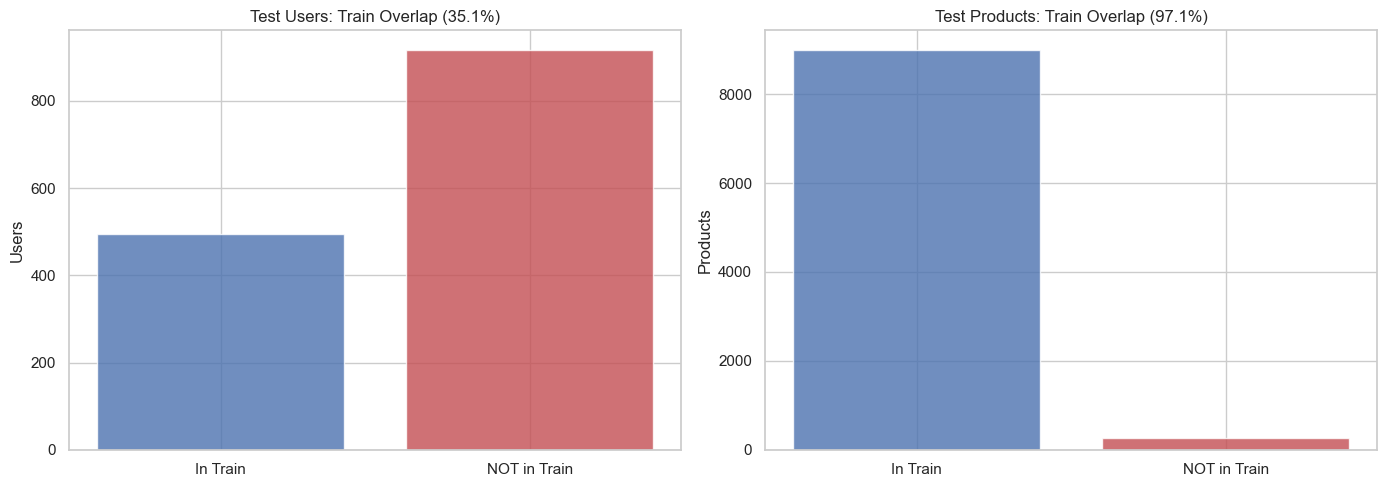

Test Set Composition by User Type:
user_type identity_type  sessions  avg_interactions  avg_products
      New     Anonymous      5932               4.0           3.4
      New         Known       920               4.1           3.6
Returning         Known       497               4.0           3.5

User Overlap:  test_users  in_train  not_in_train  overlap_pct
       1411       495           916         35.1
Product Overlap:  test_products  in_train  not_in_train  overlap_pct
          9253      8983           270         97.1


In [15]:
# Test set composition
test_composition = q("""
    SELECT
        CASE WHEN is_returning_user THEN 'Returning' ELSE 'New' END as user_type,
        CASE WHEN is_anonymous THEN 'Anonymous' ELSE 'Known' END as identity_type,
        count(*) as sessions,
        round(avg(session_interaction_count), 1) as avg_interactions,
        round(avg(unique_products_in_session), 1) as avg_products
    FROM features.feat_session_context
    GROUP BY 1, 2
    ORDER BY 1, 2
""")

# Product overlap between train and test
product_overlap = q("""
    WITH train_products AS (
        SELECT DISTINCT product_id FROM staging.stg_interactions_train
    ),
    test_products AS (
        SELECT DISTINCT product_id FROM staging.stg_interactions_test
    )
    SELECT
        count(distinct tp.product_id) as test_products,
        count(distinct tp.product_id) filter (where trp.product_id is not null) as in_train,
        count(distinct tp.product_id) filter (where trp.product_id is null) as not_in_train,
        round(count(distinct tp.product_id) filter (where trp.product_id is not null)::double /
              count(distinct tp.product_id) * 100, 1) as overlap_pct
    FROM test_products tp
    LEFT JOIN train_products trp ON tp.product_id = trp.product_id
""")

# User overlap
user_overlap = q("""
    WITH train_users AS (
        SELECT DISTINCT user_id FROM staging.stg_interactions_train WHERE user_id IS NOT NULL
    ),
    test_users AS (
        SELECT DISTINCT user_id FROM staging.stg_interactions_test WHERE user_id IS NOT NULL
    )
    SELECT
        count(distinct tu.user_id) as test_users,
        count(distinct tu.user_id) filter (where tru.user_id is not null) as in_train,
        count(distinct tu.user_id) filter (where tru.user_id is null) as not_in_train,
        round(count(distinct tu.user_id) filter (where tru.user_id is not null)::double /
              count(distinct tu.user_id) * 100, 1) as overlap_pct
    FROM test_users tu
    LEFT JOIN train_users tru ON tu.user_id = tru.user_id
""")

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# User overlap Venn-style bar
overlap_data = user_overlap.iloc[0]
axes[0].bar(['In Train', 'NOT in Train'], [overlap_data['in_train'], overlap_data['not_in_train']],
            color=['#4C72B0', '#C44E52'], alpha=0.8)
axes[0].set_title(f'Test Users: Train Overlap ({overlap_data["overlap_pct"]}%)')
axes[0].set_ylabel('Users')

# Product overlap
p_overlap = product_overlap.iloc[0]
axes[1].bar(['In Train', 'NOT in Train'], [p_overlap['in_train'], p_overlap['not_in_train']],
            color=['#4C72B0', '#C44E52'], alpha=0.8)
axes[1].set_title(f'Test Products: Train Overlap ({p_overlap["overlap_pct"]}%)')
axes[1].set_ylabel('Products')

plt.tight_layout()
plt.show()

print("Test Set Composition by User Type:")
print(test_composition.to_string(index=False))
print(f"\nUser Overlap: {user_overlap.to_string(index=False)}")
print(f"Product Overlap: {product_overlap.to_string(index=False)}")

In [16]:
# What signals exist for returning vs new test users?
returning_vs_new = q("""
    SELECT
        is_returning_user,
        count(*) as sessions,
        round(avg(session_interaction_count), 1) as avg_interactions,
        round(avg(unique_products_in_session), 1) as avg_products,
        round(avg(session_duration_seconds), 1) as avg_duration_s,
        round(avg(families_in_session), 1) as avg_families,
        round(avg(discount_view_ratio), 4) as avg_discount_ratio
    FROM features.feat_session_context
    GROUP BY 1
""")
print("Returning vs New Users in Test Set:")
print(returning_vs_new.to_string(index=False))

# For returning users: what features are available from feat_recommendation_input?
feature_availability = q("""
    SELECT
        is_returning_user,
        count(*) as sessions,
        count(user_type) as has_user_type,
        count(recency) as has_rfm,
        count(user_total_sessions) as has_behavior,
        count(user_preferred_family) as has_preferences,
        count(avg_viewed_product_cart_rate) as has_product_context
    FROM features.feat_recommendation_input
    GROUP BY 1
""")
print(f"\nFeature Availability per Test Session:")
print(feature_availability.to_string(index=False))

Returning vs New Users in Test Set:
 is_returning_user  sessions  avg_interactions  avg_products  avg_duration_s  avg_families  avg_discount_ratio
              True       497               4.0           3.5           110.5           1.9              0.0406
             False      6852               4.0           3.5           109.2           1.9              0.0608

Feature Availability per Test Session:
 is_returning_user  sessions  has_user_type  has_rfm  has_behavior  has_preferences  has_product_context
             False      6852            920      920           920                0                 6852
              True       497            497      497           497              497                  497


---
## 7. Feature Correlations

Understanding which features are correlated and which are most predictive of cart additions.

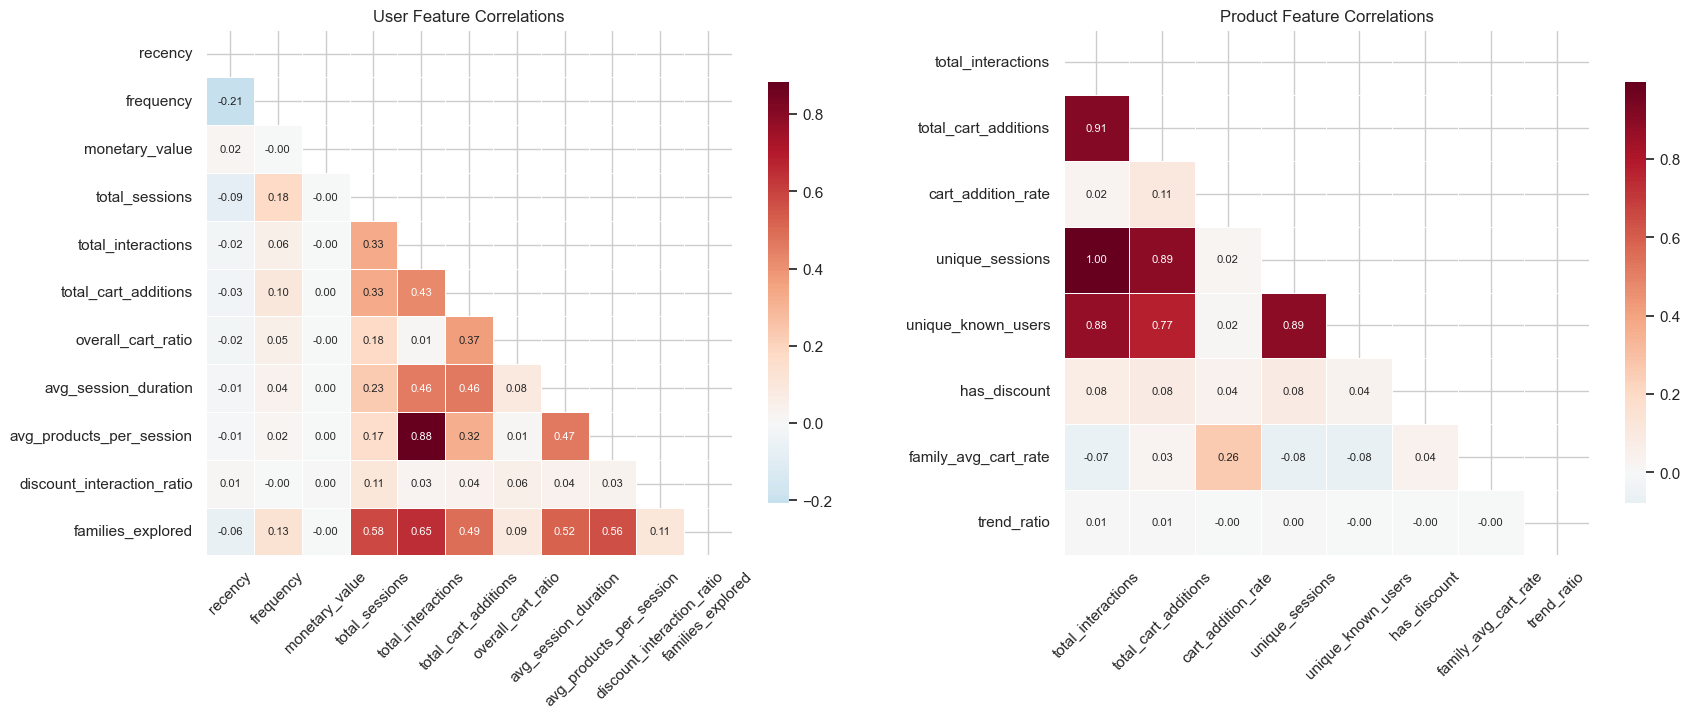

In [17]:
# User feature correlations
user_feats = q("""
    SELECT
        recency, frequency, monetary_value,
        total_sessions, total_interactions, total_cart_additions,
        overall_cart_ratio, avg_session_duration, avg_products_per_session,
        discount_interaction_ratio, families_explored
    FROM features.feat_user_behavior
    WHERE recency IS NOT NULL
""")

fig, axes = plt.subplots(1, 2, figsize=(18, 7))

# Correlation heatmap
corr = user_feats.corr()
mask = np.triu(np.ones_like(corr, dtype=bool))
sns.heatmap(corr, mask=mask, annot=True, fmt='.2f', cmap='RdBu_r', center=0,
            ax=axes[0], square=True, linewidths=0.5, cbar_kws={"shrink": 0.8},
            annot_kws={"size": 8})
axes[0].set_title('User Feature Correlations')
axes[0].tick_params(axis='x', rotation=45)

# Product feature correlations
prod_feats = q("""
    SELECT
        total_interactions, total_cart_additions, cart_addition_rate,
        unique_sessions, unique_known_users, has_discount,
        family_avg_cart_rate, trend_ratio
    FROM features.feat_product_popularity
    WHERE total_interactions > 0
""")

corr_p = prod_feats.corr()
mask_p = np.triu(np.ones_like(corr_p, dtype=bool))
sns.heatmap(corr_p, mask=mask_p, annot=True, fmt='.2f', cmap='RdBu_r', center=0,
            ax=axes[1], square=True, linewidths=0.5, cbar_kws={"shrink": 0.8},
            annot_kws={"size": 8})
axes[1].set_title('Product Feature Correlations')
axes[1].tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.show()

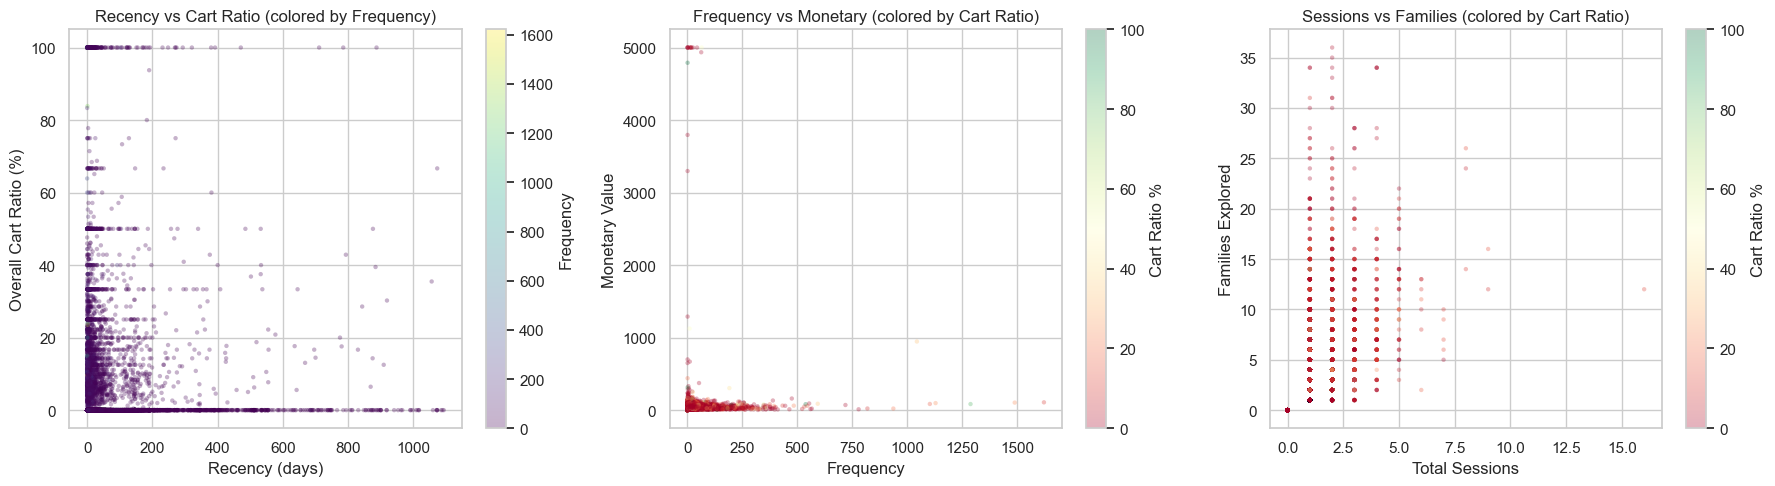

In [18]:
# RFM scatter plots colored by cart ratio
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# Sample for visualization (full dataset is too large for scatter)
sample = user_feats.sample(min(10000, len(user_feats)), random_state=42)

scatter_kw = dict(alpha=0.3, s=10, edgecolors='none')

sc = axes[0].scatter(sample['recency'], sample['overall_cart_ratio'],
                     c=sample['frequency'], cmap='viridis', **scatter_kw)
axes[0].set_title('Recency vs Cart Ratio (colored by Frequency)')
axes[0].set_xlabel('Recency (days)')
axes[0].set_ylabel('Overall Cart Ratio (%)')
plt.colorbar(sc, ax=axes[0], label='Frequency')

sc2 = axes[1].scatter(sample['frequency'], sample['monetary_value'].clip(upper=5000),
                      c=sample['overall_cart_ratio'], cmap='RdYlGn', **scatter_kw)
axes[1].set_title('Frequency vs Monetary (colored by Cart Ratio)')
axes[1].set_xlabel('Frequency')
axes[1].set_ylabel('Monetary Value')
plt.colorbar(sc2, ax=axes[1], label='Cart Ratio %')

sc3 = axes[2].scatter(sample['total_sessions'], sample['families_explored'],
                      c=sample['overall_cart_ratio'], cmap='RdYlGn', **scatter_kw)
axes[2].set_title('Sessions vs Families (colored by Cart Ratio)')
axes[2].set_xlabel('Total Sessions')
axes[2].set_ylabel('Families Explored')
plt.colorbar(sc3, ax=axes[2], label='Cart Ratio %')

plt.tight_layout()
plt.show()

---
## 8. Key Findings & Recommender Strategy

### Data Characteristics
- **85.3% anonymous sessions**: Most interactions have no user_id. This means pure collaborative filtering (user-item matrix) will only work for a small slice of the data.
- **5.9% overall conversion rate**: Heavy class imbalance. Most interactions are views, not cart additions.
- **Strong long-tail in products**: Top 1% of products dominate interactions. Many products in the catalog have zero or very few interactions.
- **16-day window**: All data spans June 1-16, 2024. Very short timeframe limits temporal patterns.

### Cold-Start Challenge
- **65% of test users are NOT in training data** (cold-start). User-based collaborative filtering alone is insufficient.
- **Product overlap is high** between train and test, so product-level signals (popularity, cart rate) are reliable.
- For cold-start users, **in-session signals** (what products they're viewing right now, device type, country) and **product popularity** are the primary available features.

### Recommender Strategy Implications
1. **Hybrid approach needed**: Combine content-based (product features, embeddings), popularity-based (global signals), and collaborative filtering (where user history exists).
2. **Session-based recommendations**: For the majority of test sessions, use what the user is viewing NOW to find similar/complementary products.
3. **Product embeddings are key**: The CV embeddings can power content-based similarity for cold-start users viewing products.
4. **Popularity fallback**: For sessions with very little signal, fall back to globally popular products weighted by category context.
5. **Discount sensitivity**: Products on discount have different conversion patterns; this should be a feature.
6. **Device type matters**: Different devices show different conversion rates, suggesting different browsing behaviors.

### Feature Priority for the Model
1. **Products viewed in the test session** (direct content signal)
2. **Product cart_addition_rate** (strongest product-level predictor)
3. **Product popularity / family popularity** (reliable global signal)
4. **User RFM + historical behavior** (available for ~35% of test users)
5. **Session context** (device, country, duration, interaction count)
6. **Product embeddings** (cosine similarity for content-based filtering)

In [19]:
# Close connection
con.close()
print("DuckDB connection closed.")

DuckDB connection closed.
